# Homework III - Programming

Grupo 55  
109247 - Ema Ferrão  
109989 - Pedro Aldeia

Consider the rent.csv dataset (available at the course’s webpage), where the goal is
to predict the price of rents based on location features and house measurements.

## Setup and Data Loading

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [2]:
# Load data
df = pd.read_csv('rent.csv')

In [3]:
# Check the dataset
print("First 5 rows:")
df.head()

First 5 rows:


,bathrooms,bedrooms,price,longitude,latitude,interest_level
0,1.5,3,3000,-73.9425,40.7145,2
1,1.0,2,5465,-73.9667,40.7947,1
2,1.0,1,2850,-74.0018,40.7388,3
3,1.0,1,3275,-73.9677,40.7539,1
4,1.0,4,3350,-73.9493,40.8241,1


In [4]:
# Display basic information
print("\n" + "=" * 150)
print("Dataset Overview:")
print("=" * 150)

print(f"Dataset shape: {df.shape}")

feature_names = df.columns[:-1].tolist()
print(f"Features ({len(feature_names)}): {feature_names}")

target_name = "price"

print(f"\nTarget variable: {target_name} -> {sorted(df[target_name].unique().tolist())}")
print(f"{target_name} distribution:")
print(df[target_name].value_counts())
print(f"{target_name} balance:")
print(df[target_name].value_counts(normalize=True).round(3))

print("\n" + "=" * 150)


Dataset Overview:
Dataset shape: (49352, 6)
Features (5): ['bathrooms', 'bedrooms', 'price', 'longitude', 'latitude']

Target variable: price -> [43, 45, 401, 695, 700, 800, 868, 950, 975, 980, 999, 1000, 1025, 1034, 1048, 1050, 1095, 1100, 1150, 1165, 1175, 1195, 1200, 1225, 1243, 1244, 1250, 1275, 1295, 1300, 1310, 1325, 1345, 1347, 1349, 1350, 1351, 1370, 1375, 1395, 1400, 1404, 1420, 1425, 1427, 1430, 1435, 1449, 1450, 1455, 1460, 1466, 1470, 1475, 1485, 1489, 1495, 1499, 1500, 1503, 1512, 1515, 1516, 1524, 1525, 1530, 1540, 1545, 1549, 1550, 1558, 1559, 1560, 1565, 1569, 1570, 1575, 1580, 1585, 1590, 1595, 1597, 1599, 1600, 1601, 1604, 1605, 1625, 1626, 1629, 1640, 1645, 1649, 1650, 1660, 1662, 1663, 1667, 1670, 1675, 1685, 1690, 1695, 1699, 1700, 1701, 1710, 1720, 1724, 1725, 1730, 1733, 1735, 1739, 1745, 1750, 1755, 1756, 1759, 1760, 1763, 1765, 1770, 1775, 1779, 1780, 1785, 1787, 1789, 1790, 1792, 1795, 1796, 1797, 1799, 1800, 1802, 1803, 1810, 1812, 1813, 1815, 1820, 1825, 18

In [5]:
# Check for missing values
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]

if len(missing_summary) > 0:
    print("Missing Values Summary:")
    print(missing_summary)
else:
    print("No missing values detected in the dataset.")

No missing values detected in the dataset.


In [6]:
# Prepare data for modeling
X = df.drop(target_name, axis=1).values
y = df[target_name].values

***
## 5. 
Train a Linear Regression model, an MLP Regressor with 2 hidden layers of 5 neurons
each and no activation functions, and another MLP Regressor with 2 hidden layers of 5
neurons each using relu activation functions. Plot a boxplot of the test MAE of each model.



5-Fold CV — Test MAE per model
- Linear Regression    | Mean: 1090.8010 | Std: 163.2555 | Min: 938.2374 | Max: 1382.0899
- MLP identity         | Mean: 1090.4453 | Std: 162.7042 | Min: 937.8074 | Max: 1381.2157
- MLP ReLU             | Mean: 1019.4239 | Std: 137.6650 | Min: 896.6848 | Max: 1273.9701


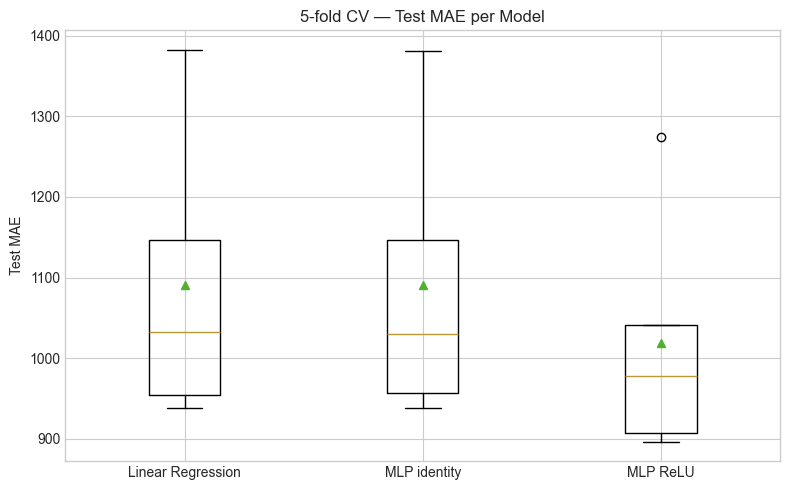

In [44]:
lin_reg = LinearRegression()

# Create MLP regressor with two hidden layer of 5 nodes
mlp_identity = MLPRegressor(
    hidden_layer_sizes=(5, 5),
    activation='identity',  # no activation function
    max_iter=2000,
    random_state=42
)

mlp_relu = MLPRegressor(
    hidden_layer_sizes=(5, 5),
    activation='relu',  # ReLU activation function
    max_iter=2000,
    random_state=42
)

models = {
    "Linear Regression": lin_reg,
    "MLP identity": mlp_identity,
    "MLP ReLU": mlp_relu
}

# Cross validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

mae_results = {name: [] for name in models}

for train_idx, val_idx in cv.split(X):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_test = y[train_idx], y[val_idx]

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)
        val_mae = mean_absolute_error(y_test, y_val_pred)
        mae_results[name].append(val_mae)

# Print summary stats
print("\n5-Fold CV — Test MAE per model")
for name, scores in mae_results.items():
    s = np.array(scores)
    print(f"- {name:20s} | Mean: {s.mean():.4f} | Std: {s.std():.4f} | Min: {s.min():.4f} | Max: {s.max():.4f}")

# Boxplot of TEST MAE for each model
plt.figure(figsize=(8, 5))
labels = list(mae_results.keys())
data = [mae_results[k] for k in labels]
plt.boxplot(data, tick_labels=labels, showmeans=True)
plt.ylabel("Test MAE")
plt.title("5-fold CV — Test MAE per Model")
plt.tight_layout()
plt.show()


***
## 2. 
Compare a Linear Regression with a MLP with relu activation, and explain the impact
and the importance of using activation functions in a MLP. Support your reasoning with the
results from the boxplots.

Activation functions are essential in neural networks because they introduce nonlinearity, allowing the model to capture complex relationships that linear models cannot. Without them, an MLP behaves like a simple linear regression, regardless of the number of layers. The boxplot results confirm this: the Linear Regression and MLP without activation show nearly identical MAE values, while the MLP with ReLU activation achieves a lower median error and less variability. This improvement demonstrates that nonlinear activations like ReLU increase the model’s expressiveness and enable it to learn intricate patterns in the data, making them crucial for capturing the complexity of real-world problems.

***
## 3. 
With a MLP with relu activation, plot the loss function for each training iteration for
both the training and validation set. Take the average across diﬀerent folds. Compare the
results and explain whether the model is overfitting, underfitting, or has good
generalization.

Our plot shows similar Training and Validation loss

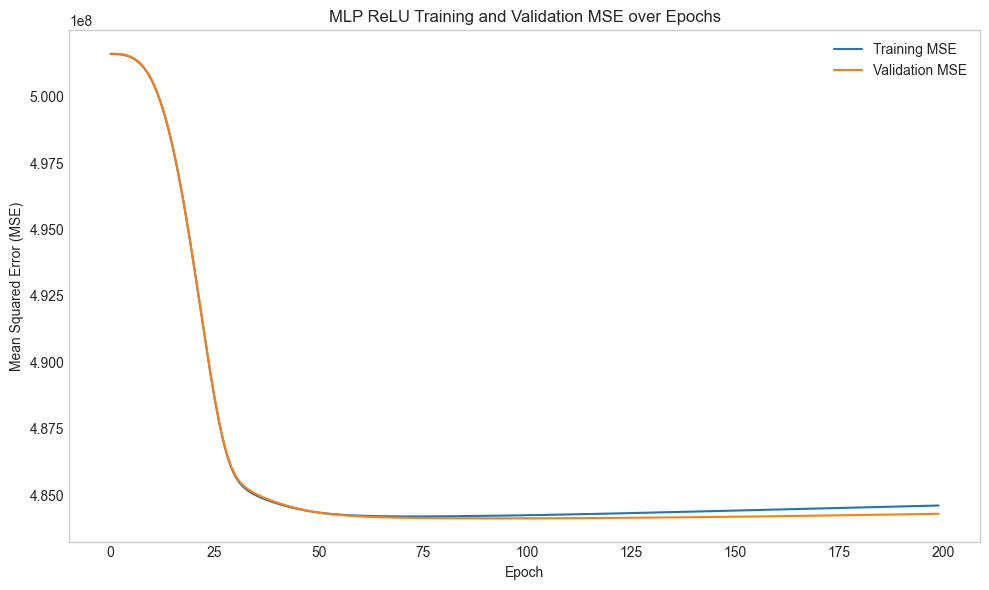

In [43]:
# Cross validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)
number_of_epochs = 200

train_mse_per_epoch_across_folds = [[] for _ in range(number_of_epochs)]
val_mse_per_epoch_across_folds = [[] for _ in range(number_of_epochs)]

for train_idx, val_idx in cv.split(X):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    mlp_relu = MLPRegressor(
        hidden_layer_sizes=(5, 5),
        activation='relu',  # ReLU activation function
        max_iter=1,
        warm_start=True,
        random_state=42
    )

    for epoch in range(number_of_epochs):
        mlp_relu.fit(X_train, y_train)
        # Predict on training set to get training MSE
        y_train_pred = mlp_relu.predict(X_train)
        train_mse = mean_squared_error(y_train, y_train_pred)
        train_mse_per_epoch_across_folds[epoch].append(train_mse)

        # Predict on validation set to get validation MSE
        y_val_pred = mlp_relu.predict(X_val)
        val_mse = mean_squared_error(y_val, y_val_pred)
        val_mse_per_epoch_across_folds[epoch].append(val_mse)

# Compute average MSE per epoch across folds
avg_train_mse_per_epoch = []
avg_val_mse_per_epoch = []

for epoch in range(number_of_epochs):
    avg_train_mse_per_epoch.append(np.mean(train_mse_per_epoch_across_folds[epoch]))
    avg_val_mse_per_epoch.append(np.mean(val_mse_per_epoch_across_folds[epoch]))

# Plot training and validation MSE over epochs
plt.figure(figsize=(10, 6))
plt.plot(range(number_of_epochs), avg_train_mse_per_epoch, label='Training MSE', color='tab:blue')
plt.plot(range(number_of_epochs), avg_val_mse_per_epoch, label='Validation MSE', color='tab:orange')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MLP ReLU Training and Validation MSE over Epochs')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


The training and validation MSE both decrease sharply during the first 30 epochs, indicating that the model is learning the main data patterns and reducing its prediction error rapidly. After about epoch 30, the curves flatten, suggesting that the model has reached convergence and further training brings minimal improvement.

The training and validation curves remain very close throughout the process, which indicates that the model generalizes well and is neither underfitting nor overfitting. Interestingly, the validation MSE becomes slightly lower than the training MSE after convergence, suggesting that the validation data may be marginally easier to model.

Overall, the model converged quickly and exhibits stable learning behavior, achieving similar performance on both training and validation sets, which suggests a well-balanced architecture and effective generalization.